## Analyze the shopping trend dataset by answering the questions below.
> **IMPORTANT** write your insights after each question

# Read the data

In [48]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "shopping_trends_updated.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "iamsouravbanerjee/customer-shopping-trends-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipython-input-1162196871.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'customer-shopping-trends-dataset' dataset.


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### Question 1
What is the distribution of `Purchase Amount (USD)` for different `Subscription Status` values?
- Plot using both **Seaborn’s `boxplot` and Matplotlib’s histogram**.
- Are there any outliers?

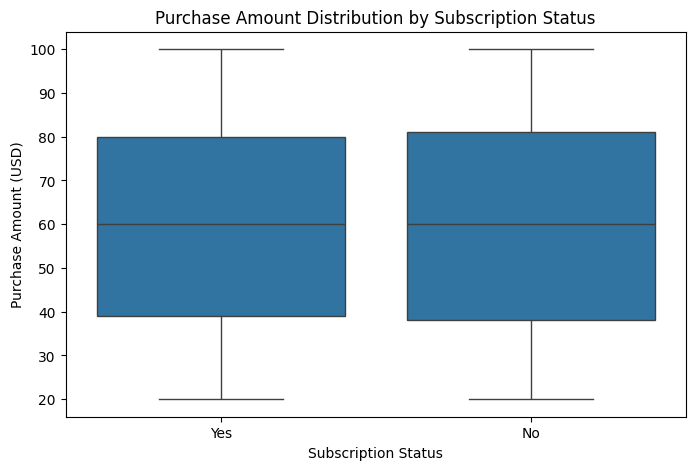

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Subscription Status',
    y='Purchase Amount (USD)',
    data=df
)
plt.title('Purchase Amount Distribution by Subscription Status')
plt.show()


In [50]:

## NO , THERE ARE NO OUTLIERS

### Question 2
Compare the frequency of each `Payment Method` across the dataset **from highest to lowest** .
- Use both **Seaborn's `countplot`** and **Matplotlib's bar plot**.

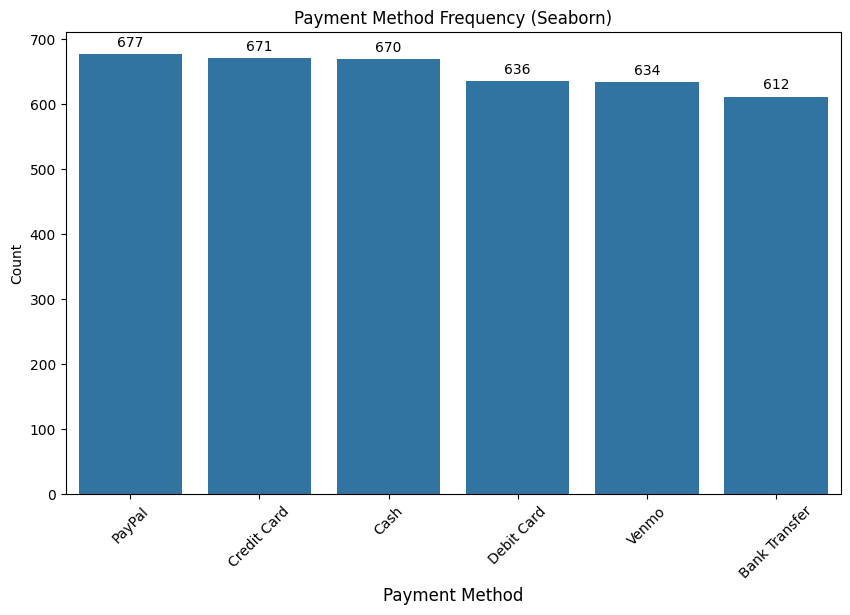

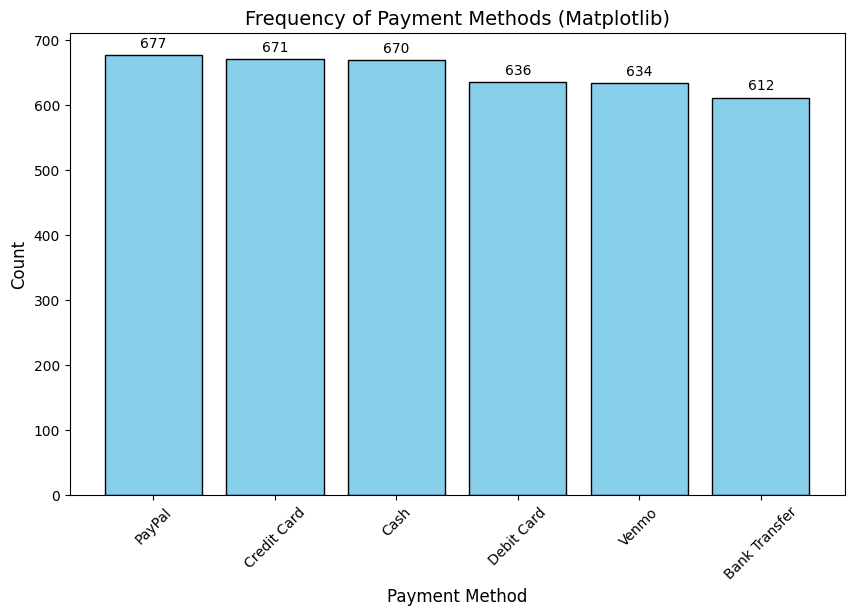

In [ ]:



order = df['Payment Method'].value_counts().index
counts = df['Payment Method'].value_counts()

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Payment Method', order=df['Payment Method'].value_counts().index)


for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Payment Method Frequency (Seaborn)')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Count', fontsize=10)
plt.xticks(rotation=45)
plt.show()


plt.figure()

bars = plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')


plt.bar_label(bars, fmt='%d', padding=3)

plt.title('Frequency of Payment Methods (Matplotlib)', fontsize=14)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Question 3
Show the number of purchases made by each `Gender` in each `Season`.
- Create a **grouped bar chart/ Pie chart using Matplotlib**.
- Also plot a **stacked countplot using Seaborn**.

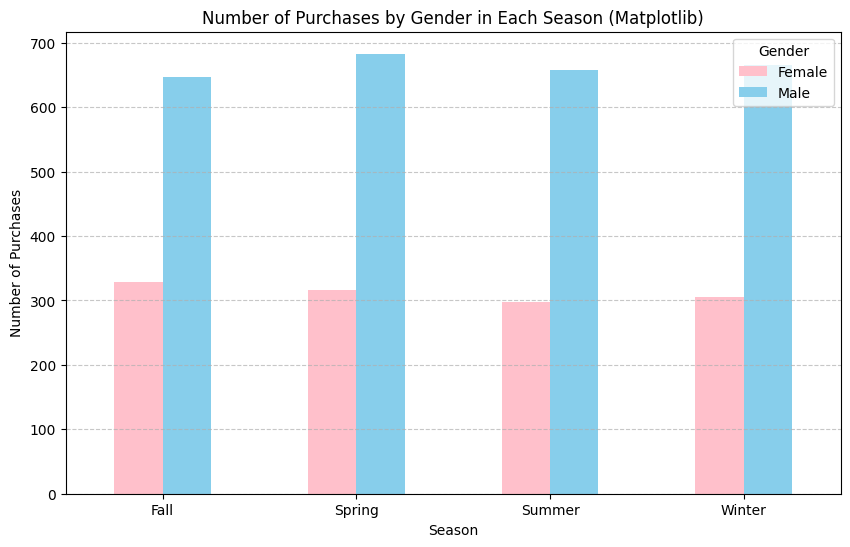

In [ ]:



gender_season_counts = df.pivot_table(index='Season', columns='Gender', aggfunc='size')


gender_season_counts.plot(kind='bar', figsize=(10, 6), color=['pink', 'skyblue'])

plt.title('Number of Purchases by Gender in Each Season (Matplotlib)')
plt.xlabel('Season')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

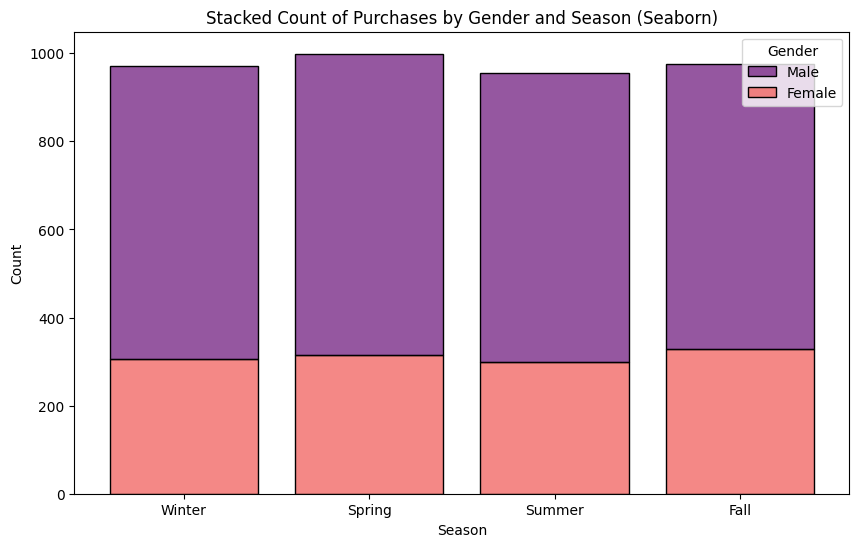

In [ ]:
plt.figure(figsize=(10, 6))


sns.histplot(data=df, x='Season', hue='Gender', multiple='stack', shrink=.8, palette='magma')

plt.title('Stacked Count of Purchases by Gender and Season (Seaborn)')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

### Question 4
Create a heatmap showing the correlation between all numeric columns.
- Use `sns.heatmap`.
- Interpret the relationship between `Previous Purchases`, `Purchase Amount`, and `Review Rating`.

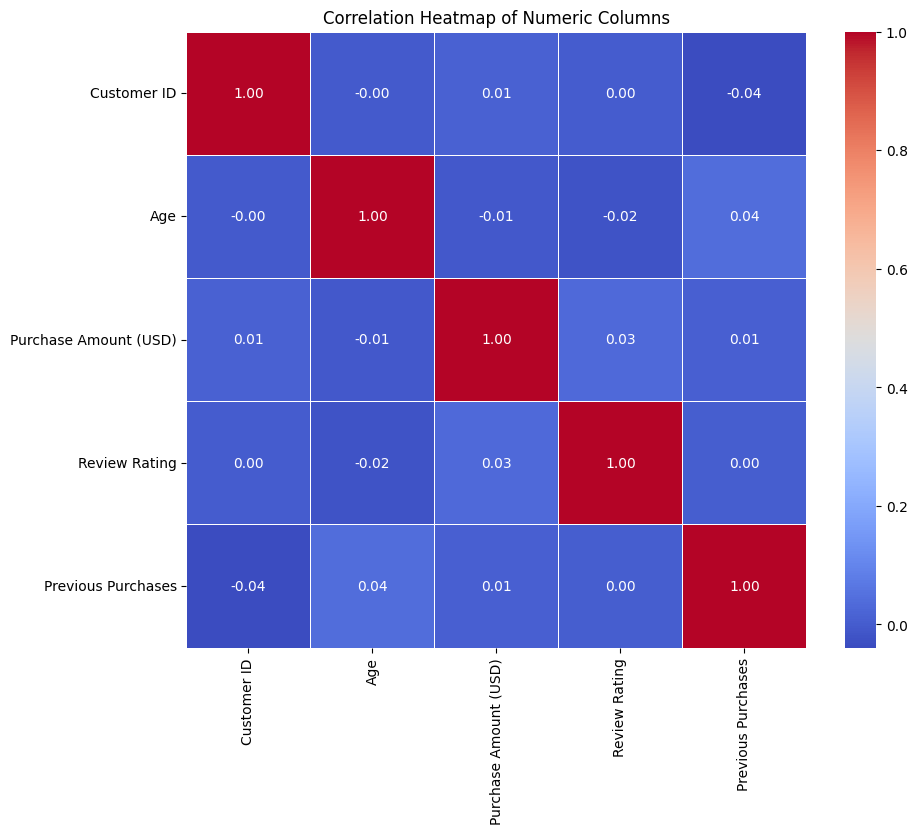

In [ ]:


numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

### Question 5
Create a scatter plot of `Age` vs `Purchase Amount (USD)`, color-coded by `Gender`.
- Use **Matplotlib and Seaborn side-by-side**.
- Add a trend line in Seaborn using `regplot`.

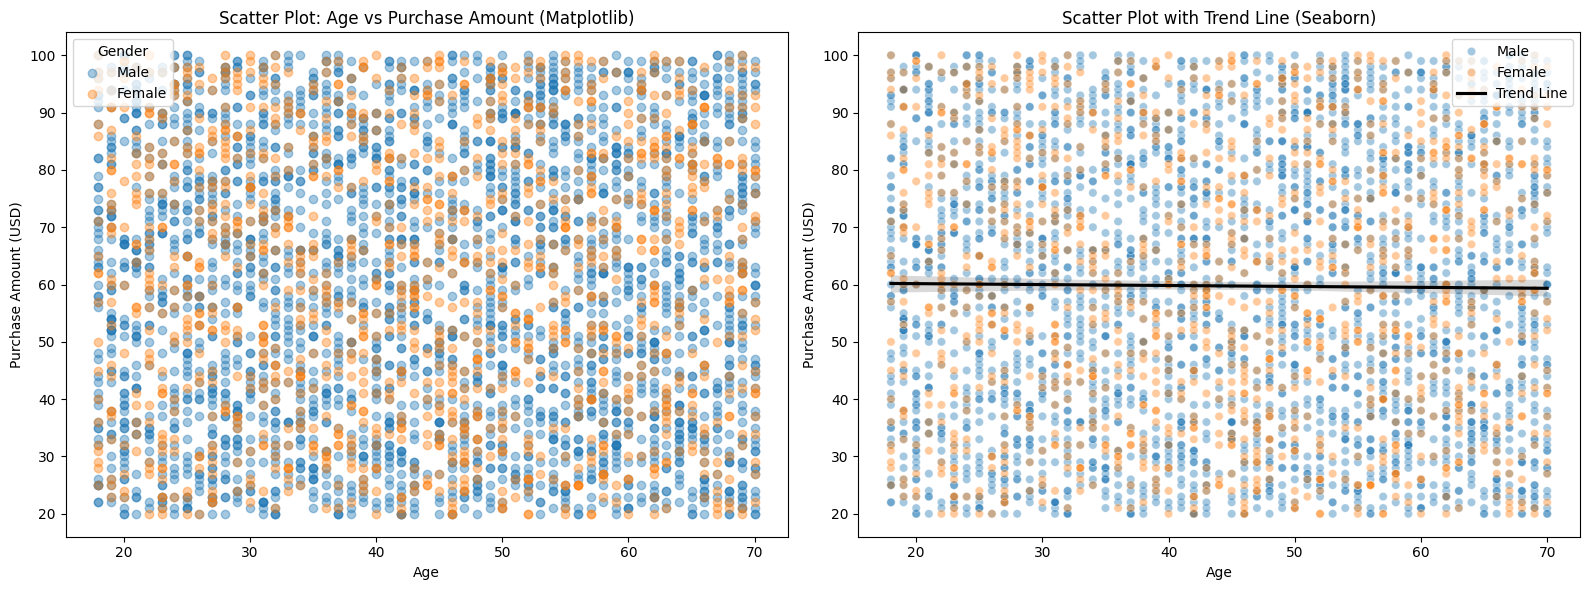

In [ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender]
    ax1.scatter(subset['Age'], subset['Purchase Amount (USD)'], label=gender, alpha=0.4)

ax1.set_title('Scatter Plot: Age vs Purchase Amount (Matplotlib)')
ax1.set_xlabel('Age')
ax1.set_ylabel('Purchase Amount (USD)')
ax1.legend(title='Gender')


sns.scatterplot(data=df, x='Age', y='Purchase Amount (USD)', hue='Gender', ax=ax2, alpha=0.4)
sns.regplot(data=df, x='Age', y='Purchase Amount (USD)', scatter=False, ax=ax2, color='black', label='Trend Line')

ax2.set_title('Scatter Plot with Trend Line (Seaborn)')
ax2.set_xlabel('Age')
ax2.set_ylabel('Purchase Amount (USD)')
ax2.legend()

plt.tight_layout()
plt.show()

### Question 6
How does the average review rating differ across different item `Categories` and `Sizes`?
- Use **Seaborn’s heatmap or pivot heatmap** to visualize.
- Use Pandas pivot table to prepare the data.

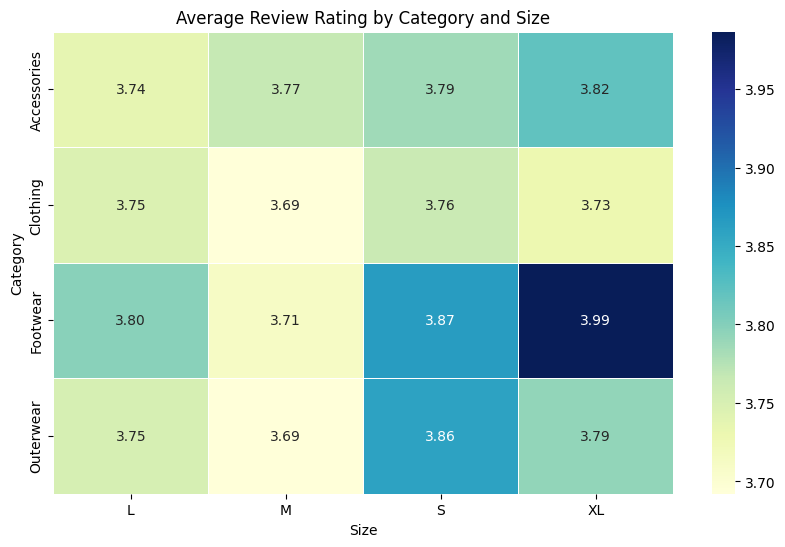

In [ ]:

pivot_data = df.pivot_table(index='Category',
                            columns='Size',
                            values='Review Rating',
                            aggfunc='mean')

# 3. رسم الـ Heatmap باستخدام Seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)

plt.title('Average Review Rating by Category and Size')
plt.xlabel('Size')
plt.ylabel('Category')
plt.show()

### Question 7
Which combinations of `Season` and `Shipping Type` lead to the highest average `Purchase Amount (USD)`?
- Show this as a **grouped bar chart** and as a **heatmap**.

/tmp/ipython-input-1702343403.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Season', y='Purchase Amount (USD)', hue='Shipping Type', ci=None)


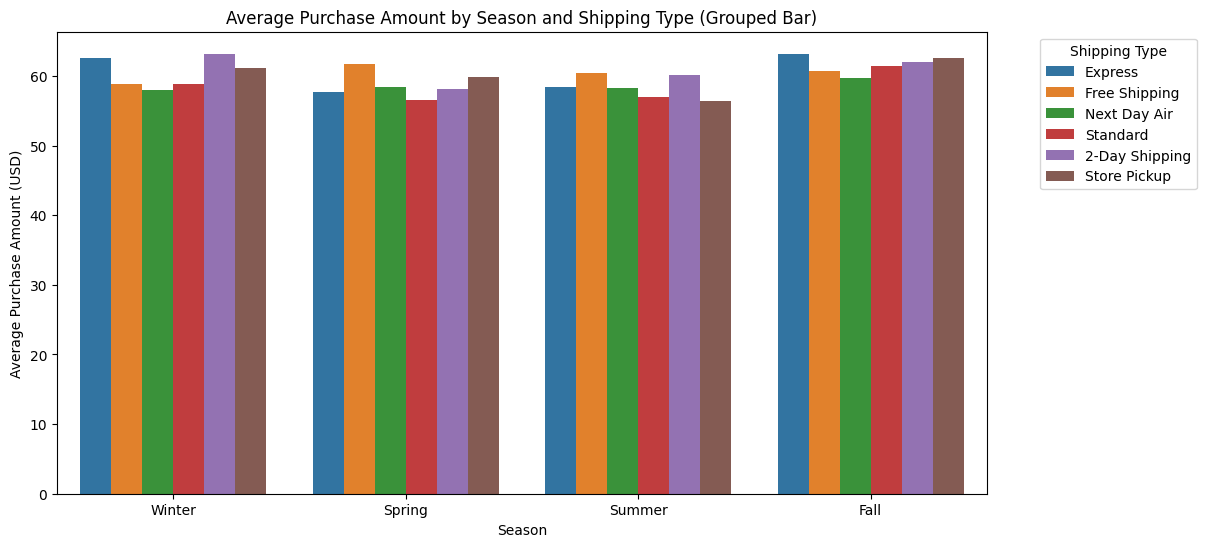

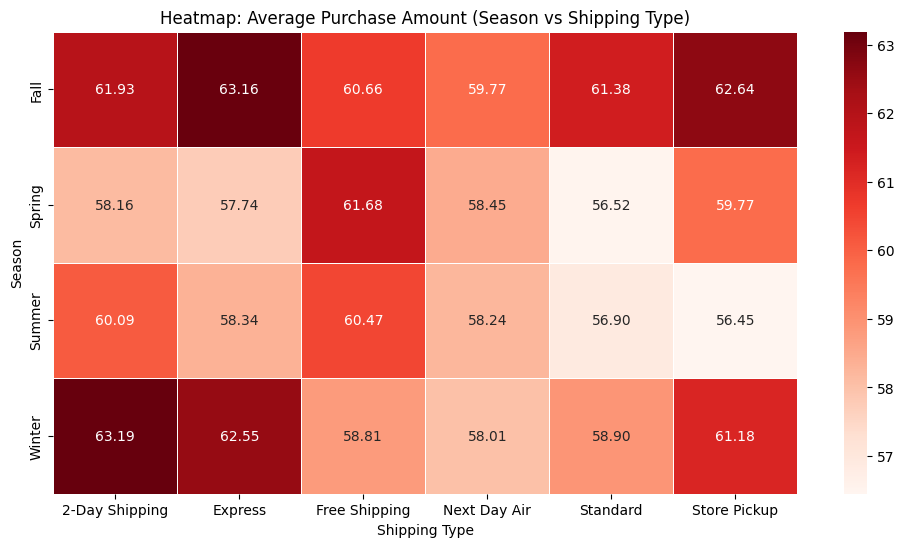

In [ ]:



avg_purchase_pivot = df.pivot_table(index='Season',
                                    columns='Shipping Type',
                                    values='Purchase Amount (USD)',
                                    aggfunc='mean')


plt.figure(figsize=(12, 6))

sns.barplot(data=df, x='Season', y='Purchase Amount (USD)', hue='Shipping Type', ci=None)

plt.title('Average Purchase Amount by Season and Shipping Type (Grouped Bar)')
plt.ylabel('Average Purchase Amount (USD)')
plt.legend(title='Shipping Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


plt.figure(figsize=(12, 6))
sns.heatmap(avg_purchase_pivot, annot=True, cmap='Reds', fmt=".2f", linewidths=0.5)

plt.title('Heatmap: Average Purchase Amount (Season vs Shipping Type)')
plt.xlabel('Shipping Type')
plt.ylabel('Season')
plt.show()

### Question 8
Plot a violin plot of `Review Rating` by `Gender` for each `Subscription Status`.
- Use `sns.violinplot` with `hue`.

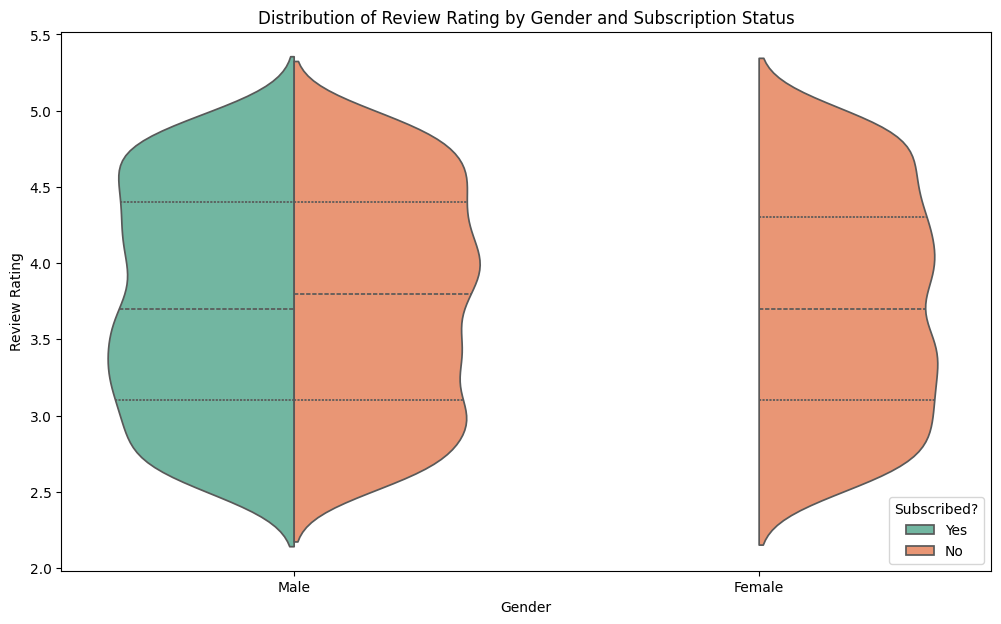

In [58]:



plt.figure(figsize=(12, 7))

sns.violinplot(data=df, x='Gender', y='Review Rating', hue='Subscription Status',
               split=True, inner="quart", palette="Set2")

plt.title('Distribution of Review Rating by Gender and Subscription Status')
plt.xlabel('Gender')
plt.ylabel('Review Rating')
plt.legend(title='Subscribed?', loc='lower right')
plt.show()

### Question 9
What are the top 5 most purchased `Item Purchased` by total `Purchase Amount`?
- Use Pandas aggregation, plot with **Matplotlib pie and bar** charts.

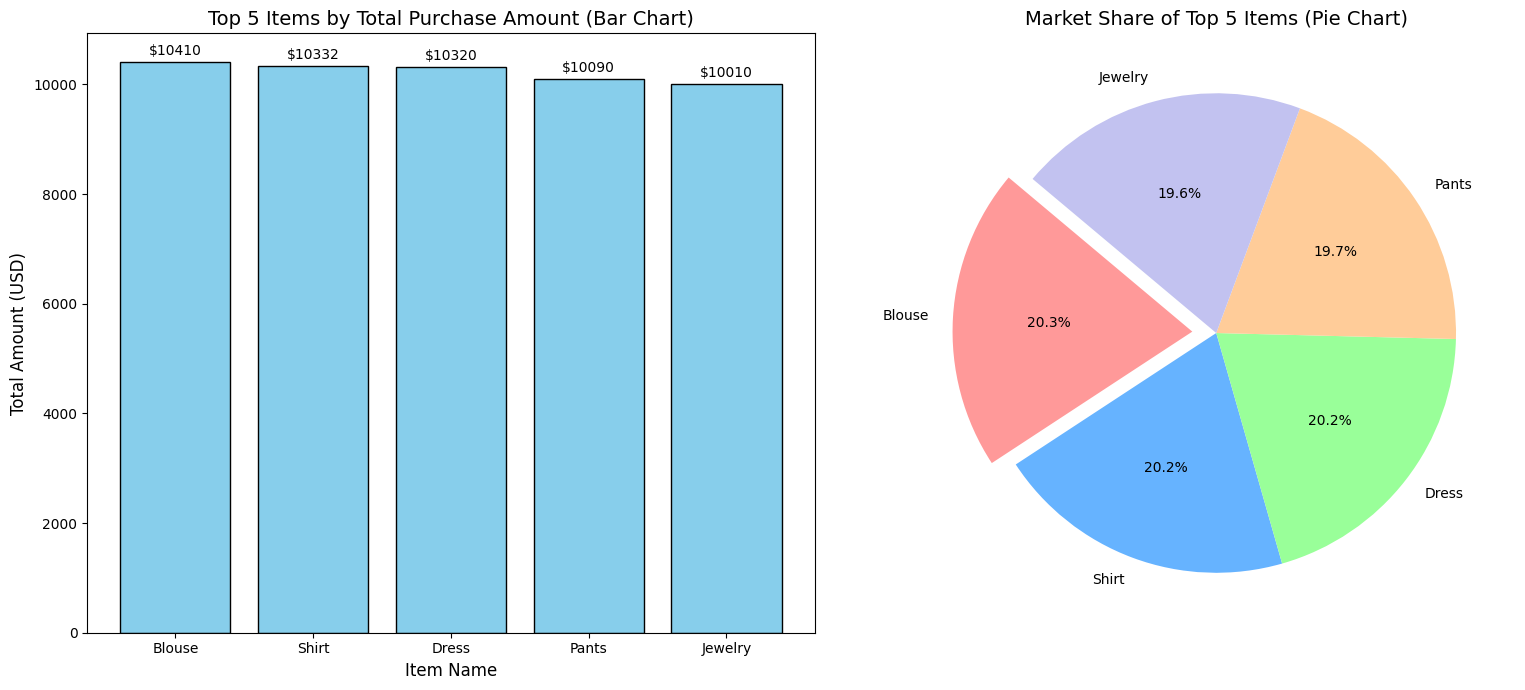

Top 5 Purchased Items:
Item Purchased
Blouse     10410
Shirt      10332
Dress      10320
Pants      10090
Jewelry    10010
Name: Purchase Amount (USD), dtype: int64


In [59]:



top_5_items = df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().nlargest(5)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))


bars = ax1.bar(top_5_items.index, top_5_items.values, color='skyblue', edgecolor='black')
ax1.set_title('Top 5 Items by Total Purchase Amount (Bar Chart)', fontsize=14)
ax1.set_xlabel('Item Name', fontsize=12)
ax1.set_ylabel('Total Amount (USD)', fontsize=12)

ax1.bar_label(bars, fmt='$%.0f', padding=3)


ax2.pie(top_5_items, labels=top_5_items.index, autopct='%1.1f%%',
        startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'],
        explode=[0.1, 0, 0, 0, 0])
ax2.set_title('Market Share of Top 5 Items (Pie Chart)', fontsize=14)

plt.tight_layout()
plt.show()


print("Top 5 Purchased Items:")
print(top_5_items)

### Question 10
Which `Location` has the highest average `Purchase Amount`, and how does it relate to `Previous Purchases` (plot only top 5 purchase amount location)?
- Use a **Seaborn scatterplot** with size/marker variation.

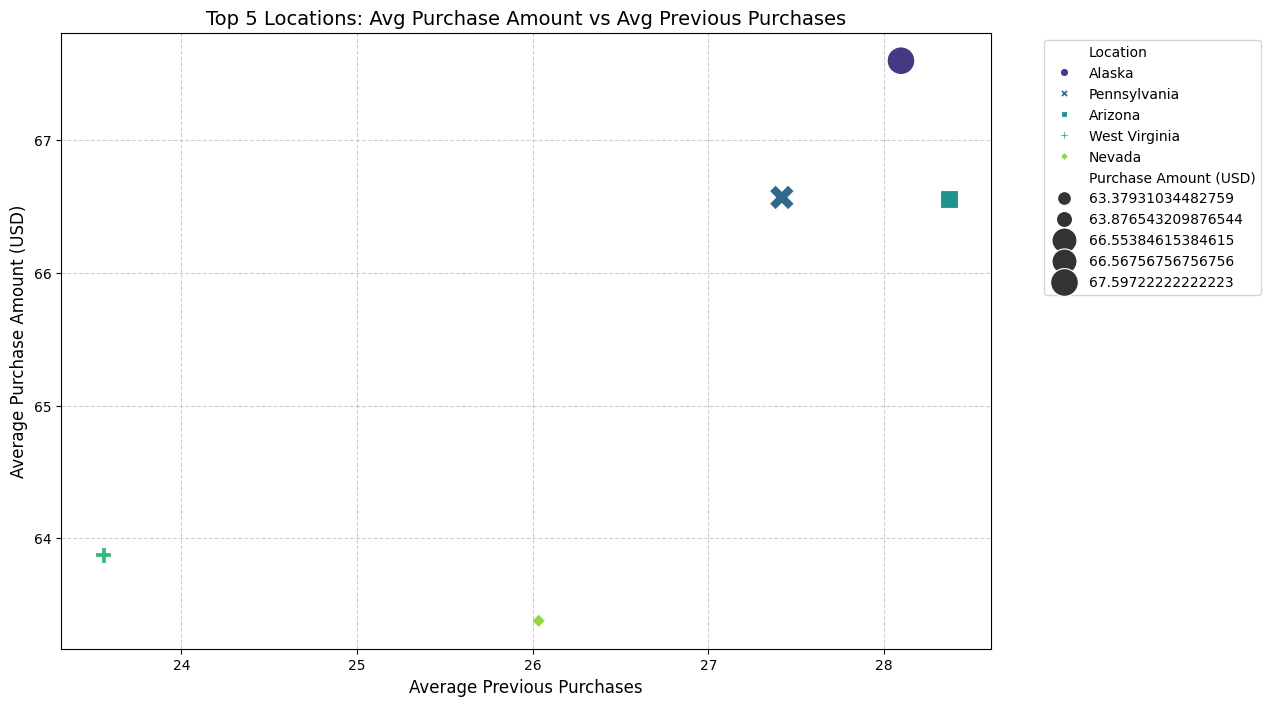

The location with the highest average purchase amount is: Alaska ($67.60)


In [60]:



location_stats = df.groupby('Location').agg({
    'Purchase Amount (USD)': 'mean',
    'Previous Purchases': 'mean'
}).reset_index()


top_5_locations = location_stats.nlargest(5, 'Purchase Amount (USD)')


plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=top_5_locations,
    x='Previous Purchases',
    y='Purchase Amount (USD)',
    hue='Location',
    style='Location',
    size='Purchase Amount (USD)',
    sizes=(100, 400),
    palette='viridis'
)


plt.title('Top 5 Locations: Avg Purchase Amount vs Avg Previous Purchases', fontsize=14)
plt.xlabel('Average Previous Purchases', fontsize=12)
plt.ylabel('Average Purchase Amount (USD)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


highest_loc = top_5_locations.iloc[0]
print(f"The location with the highest average purchase amount is: {highest_loc['Location']} (${highest_loc['Purchase Amount (USD)']:.2f})")

### Question 11
Using a crosstab, find how `Gender` and `Size` interact.
- Plot using `sns.heatmap`.

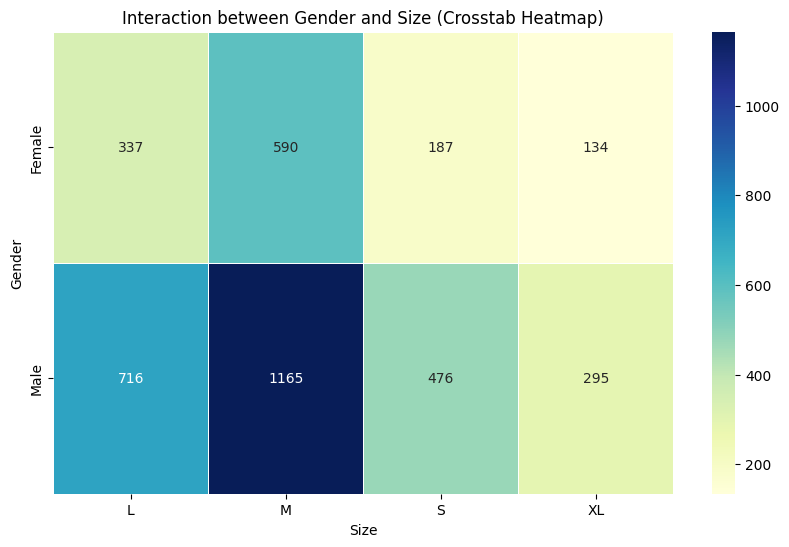

In [61]:
import pandas as pd

gender_size_xtab = pd.crosstab(df['Gender'], df['Size'])


plt.figure(figsize=(10, 6))
sns.heatmap(gender_size_xtab, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)

plt.title('Interaction between Gender and Size (Crosstab Heatmap)')
plt.xlabel('Size')
plt.ylabel('Gender')
plt.show()

### Question 12
How does the frequency of purchases column influence the use of promo codes?
- Create a **stacked bar chart** using Matplotlib and compare with a **Seaborn countplot**.

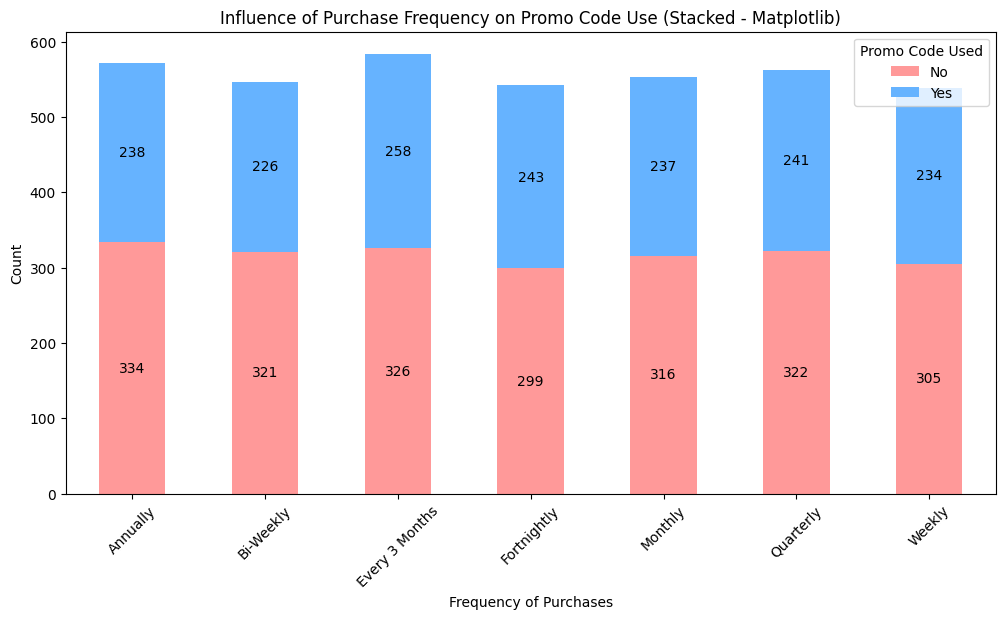

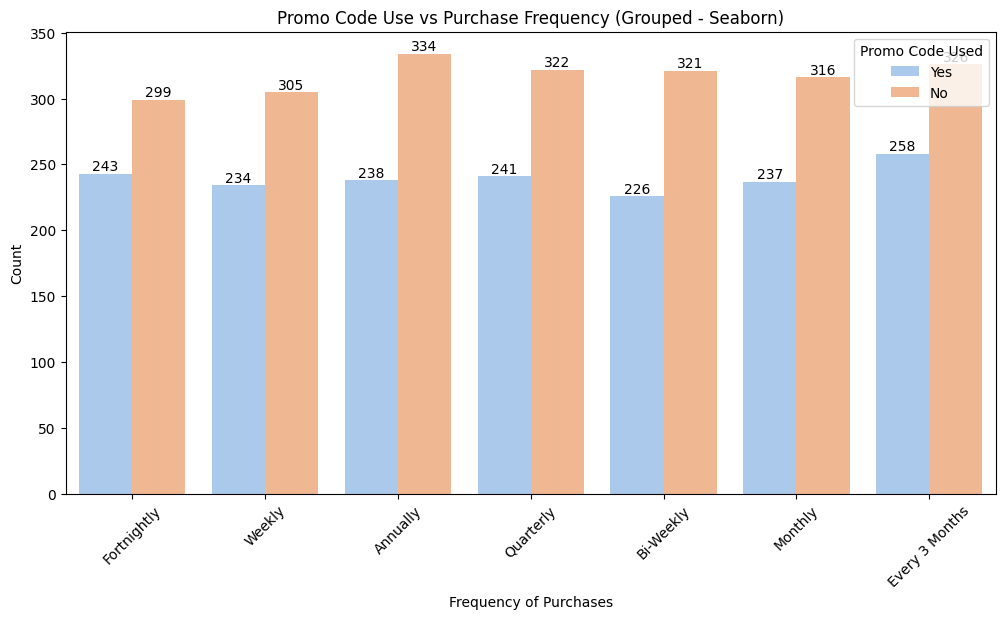

In [62]:



promo_freq_xtab = pd.crosstab(df['Frequency of Purchases'], df['Promo Code Used'])


ax1 = promo_freq_xtab.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999', '#66b3ff'])
plt.title('Influence of Purchase Frequency on Promo Code Use (Stacked - Matplotlib)')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Count')
plt.legend(title='Promo Code Used')
plt.xticks(rotation=45)


for container in ax1.containers:
    ax1.bar_label(container, label_type='center')

plt.show()


plt.figure(figsize=(12, 6))

ax2 = sns.countplot(data=df, x='Frequency of Purchases', hue='Promo Code Used', palette='pastel')

for container in ax2.containers:
    ax2.bar_label(container)

plt.title('Promo Code Use vs Purchase Frequency (Grouped - Seaborn)')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Question 13
Using a pairplot, show pairwise relationships between numeric columns segmented by `Gender`.
- Use `sns.pairplot` with `hue="Gender"`.

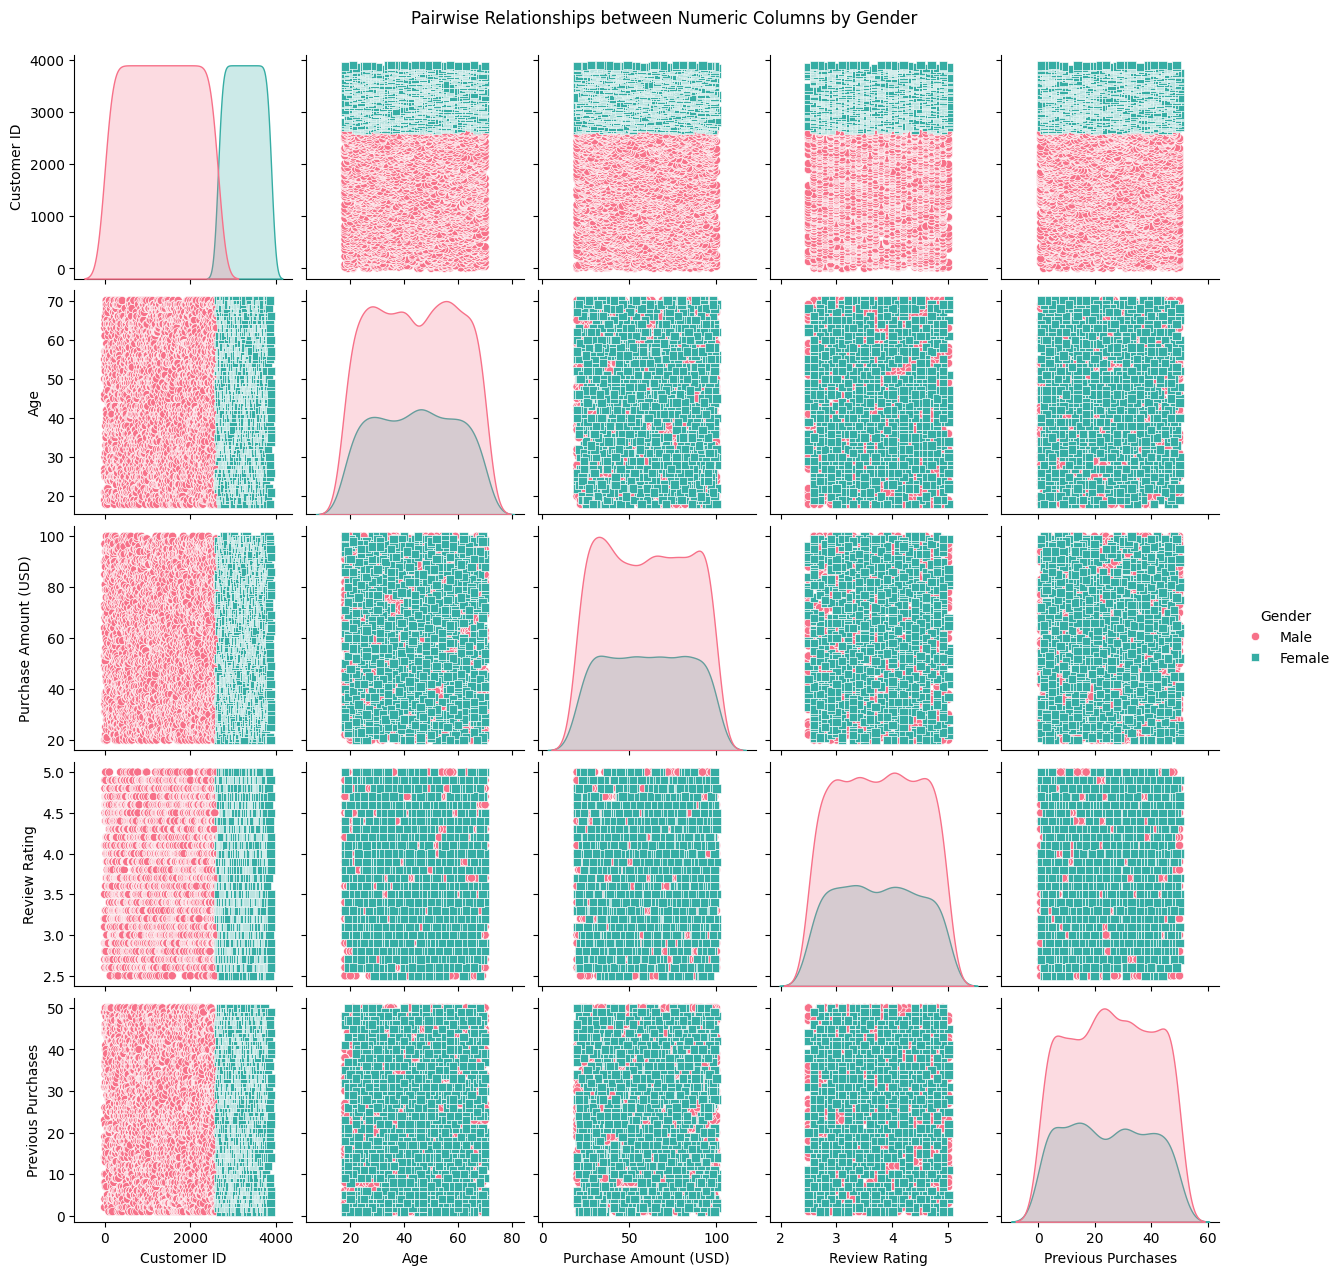

In [63]:


g = sns.pairplot(df, hue="Gender", palette="husl", diag_kind="kde", markers=["o", "s"])

g.fig.suptitle('Pairwise Relationships between Numeric Columns by Gender', y=1.02)

plt.show()

In [64]:
# حفظ نسخة من البيانات في فولدر المشروع الحالي
df.to_csv('shopping_trends_updated.csv', index=False)